In [1]:
import bigfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from nbodykit.lab import BigFileCatalog
from scipy.spatial import distance

import find_particle_groups as fp  # imports python script we have been working on

### Notes to self/selves/others

The point of this notebook is twofold: to easily display the functionality of the script we have written for finding particles and their associated halos, and also to get an idea of possible working pipelines we can have for any future work involving these data structures (ie. for using a different run on MP-Gadget with a higher resolution). Given the second point, most code cells in this notebook are independent, meaning they can be run on their own (with the exception of the first two cells for package and snapshot imports). 

Here we use the term 'group' and 'halo' interchangeably, as in the data the former term is used but in reality the latter is what is described by this. 

A check has been performed using the attribute file corresponding to the PIG file (all of this so far is for 006, the final snapshot at a scale factor of 1) that tells us the following:

- NumFOFGroupsTotal = 1988
- NumPartInGroupTotal = 124481

This corresponds nicely to the results we see in the snapshot file (PART_00X), which shows that there are 1988 unique group IDs (verified below). For whatever confusing reason, the particles that do **not** correspond to a group are labeled as belonging to group ID 4294967295 instead of -1. Subtracting all of the particles that belong to this group ID from the total number of particles used in the simulation gratifyingly gives a result of 124481, the expected number of particles that do belong to a group. 

In [2]:
# Snapshot imports to obtain DM particle attributes
snapshot = '/home/aschann/MP-Gadget/DM_Halos_March10/output/PART_006'

# Look at DM particles only
data = BigFileCatalog(snapshot, dataset='1/', header='Header')

# Get data without "lazy " array retrieval (yet)
pos = data['Position']
groupID = data['GroupID']

/home/aschann/miniconda/envs/test/lib/python3.6/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


In [3]:
# Get all the unique group IDs that exist in the data
fp.get_all_unique_ids(groupID)

(2097152,)
Unique group IDs:  [         1          2          3 ...       1987       1988 4294967295]
Total number of group IDs:  1989


In [4]:
# Get N number of most populated groups (groups with the highest number of particles)
fp.get_N_largest_ids(groupID, N=10)  # Ungrouped particles account for the highest number of course

Top N Group IDs with highest number of particles: 
Group ID: 4294967295, Count: 1972671
Group ID: 1, Count: 655
Group ID: 2, Count: 363
Group ID: 3, Count: 355
Group ID: 4, Count: 354
Group ID: 5, Count: 352
Group ID: 6, Count: 352
Group ID: 7, Count: 345
Group ID: 8, Count: 327
Group ID: 9, Count: 326


In [14]:
# Get array of most statistically significant groups/halos
sigma = 3
target_ids, target_counts = fp.get_significant_groups(groupID, sigma=sigma)
print(f"ID for groups above sigma = {sigma}: ", target_ids, "\n")
print("Number of particles in group: ", target_counts)

ID for groups above sigma = 3:  [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47] 

Number of particles in group:  [655 363 355 354 352 352 345 327 326 314 311 311 306 300 298 275 273 270
 269 261 249 248 246 246 242 228 228 227 223 223 220 216 216 214 213 213
 212 211 207 205 205 204 202 202 202 201 199]


{1: array([ 90.8224966 , 303.20399135, 342.06811326]), 2: array([216.66321695, 388.9863642 ,  27.84365819]), 3: array([365.94182774, 248.97012751, 296.20746094]), 4: array([101.08310434, 238.26943759, 303.84884702]), 5: array([176.70887663, 260.31737729, 227.87320266]), 6: array([360.81373645, 205.17207368, 181.12375384]), 7: array([145.4411157 , 460.0254652 , 424.31254214]), 8: array([181.86693828, 207.99515765, 351.51927669]), 9: array([ 43.92822012, 338.84403508, 175.18787135]), 10: array([ 30.00170149, 481.38303484,  13.25497396]), 11: array([ 14.95767474, 454.32905815,  70.83198561]), 12: array([309.67294876, 444.55835559, 110.4361713 ]), 13: array([353.85458913, 246.62570466, 149.1569702 ]), 14: array([161.11711154, 438.06292117, 374.20321289]), 15: array([ 87.61799798, 336.49195761,   8.90977772]), 16: array([294.08580191, 167.06921594, 483.02702597]), 17: array([365.62309077, 158.64947737, 109.11228884]), 18: array([307.00251636, 328.24772608, 158.07866288]), 19: array([304.675

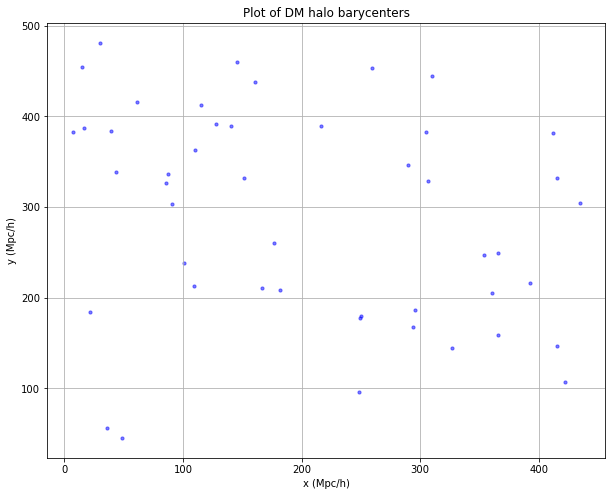

In [15]:
# Retrieve and plot barycenters of halos
barycenters =  fp.calculate_barycenters(pos, groupID, target_ids=target_ids) 
print(barycenters)

fp.plot_2D_barycenters(barycenters) 
#fp.plot_3D_barycenters(barycenters) # <-----Or plot barycenters in 3D

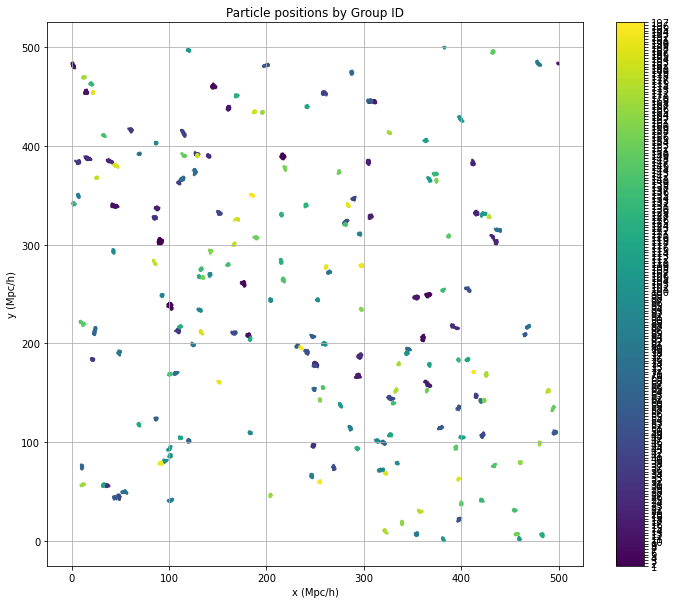

In [17]:
# Filter particles by group ID, then plot particles for those groups 
target_ids, target_counts = fp.get_significant_groups(groupID, sigma=1)

# returns dictionary of particles with target IDs
target_particles = fp.filter_particles_by_group(pos, groupID, target_ids=target_ids) 

# Plot in 2D
fp.plot_particle_groups(particle_dict=target_particles, target_ids=target_ids)

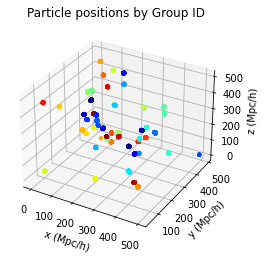

In [8]:
# Filter particles by group ID, then plot particles for those groups 
target_ids, target_counts = fp.get_significant_groups(groupID, sigma=3)

target_particles = fp.filter_particles_by_group(pos, groupID, target_ids=target_ids) 

# OR plot in 3D
fp.plot_3D_particle_groups(particle_dict=target_particles, target_ids=target_ids)

Closest group IDs to specified points:  {(167, 209): 46, (182, 206): 8}


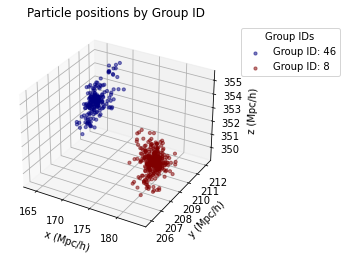

In [9]:
# Find group ID related to particles near a point of interest
#Requires having dictionary of particle group IDs and coordinates 
target_ids, target_counts = fp.get_significant_groups(groupID, sigma=3)

target_particles = fp.filter_particles_by_group(pos, groupID, target_ids=target_ids)

# Looking for group IDs of the two halo groups we chose that are relatively close and isolated 
# -- visualized by above pipeling, notably plotting 2D particle groups of target IDs

points_of_interest = [(167, 209), (182,206)] # indicate points you want to search near as a tuple

# Get dictionary of groups associated to the points we give
target_groups = fp.find_closest_groups(target_particles, points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Convert target group IDs to list to use later
target_groups = list(target_groups.values())

# Plot two halos of interest
fp.plot_3D_particle_groups(particle_dict=target_particles, target_ids=target_groups, legend=True)

In [10]:
# Compute distances of each barycenter to a given group ID and return the closest distances
barycenter_distances_46 = fp.compute_distances_to_barycenters(pos, groupID, target_id=46, N =10)
barycenter_distances_46

{1216: 4.119605296153578,
 1214: 12.23372354321174,
 8: 15.535311682147615,
 121: 18.36076957090546,
 399: 21.22171837682879,
 848: 22.874743025064358,
 291: 25.422999671989853,
 257: 25.834266177494015,
 618: 27.157845472430203,
 1572: 29.165062810351596}

## Goals for tomorrow

Maybe we can set up another jupyter notebook to more easily explore the other attributes given for DM particles?
ie. we can look at the potential directly (likely using this same **.compute()** method) as well as the velocities?

Boily mentioned something about getting a vector for each group or particle and that in total it should add to 0 (I dont remember right now exactly), maybe we can look into that?

In [11]:
# ie. other attributes to look at (ignore mass it should be uniform)
!ls output/PART_006/1/

GroupID  ID  Mass  Position  Potential	Velocity
